## Modeling
In this notebook I test out different models and how they work on the dataset.

In [ ]:
import pandas as pd

# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..')) # This is to ensure the path gets found correctly

import script.data_preprocessing as dp
import script.data_visualization as dv
import script.data_modeling as dm
import script.anomaly_detection as ad

In [2]:
# load in the data
X_train, X_val, X_test, y_train, y_val, y_test = dp.load_split_data('dataset1')

In [3]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Anomaly,Flow rate (Mean)_rolling_mean_10,...,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10,Anomaly_rolling_mean_10,Anomaly_rolling_std_10,Anomaly_rolling_min_10,Anomaly_rolling_max_10
0,3.769735,3.891036,3.855507,3.851978,-5.461369,-8.634564,-6.094472,0.705783,0,3.769339,...,-6.132574,-6.102468,0.706074,-0.150213,0.746822,0.665663,-0.109654,-0.011509,-0.109217,-0.109855
1,3.769277,3.913425,3.872355,3.880656,-5.523070,-8.705175,-6.120487,0.671932,0,3.769110,...,-6.159397,-6.102468,0.689142,-0.150213,0.712944,0.665663,-0.109654,-0.011509,-0.109217,-0.109855
2,3.769735,3.918827,3.902206,3.917088,-5.476060,-8.621725,-6.113054,0.711426,0,3.769186,...,-6.159397,-6.102468,0.696668,-0.399507,0.712944,0.671305,-0.109654,-0.011509,-0.109217,-0.109855
3,3.766759,3.889493,3.872355,3.874455,-5.487812,-8.698756,-6.116771,0.694498,0,3.768481,...,-6.159397,-6.102468,0.696198,-0.776360,0.712944,0.671305,-0.109654,-0.011509,-0.109217,-0.109855
4,3.766302,3.894123,3.890171,3.886086,-5.478998,-8.711594,-6.113054,0.705783,0,3.767966,...,-6.159397,-6.102468,0.698173,-0.941713,0.712944,0.671305,-0.109654,-0.011509,-0.109217,-0.109855


In [4]:
y_train.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Plug_future, dtype: float64

### Baseline model

In [5]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.772     1.000     0.872      1221
         1.0      0.000     0.000     0.000       360

    accuracy                          0.772      1581
   macro avg      0.386     0.500     0.436      1581
weighted avg      0.596     0.772     0.673      1581

Validation F1 Score: 0.673


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### RandomForestClassifier

In [6]:
model = dm.train_and_evaluate_rf(X_train, X_val, y_train, y_val)

Validation F1 Score: 0.835


### Check feature importance / redundancy

In [7]:
feat_imp = dp.get_feature_importance(model, X_train)

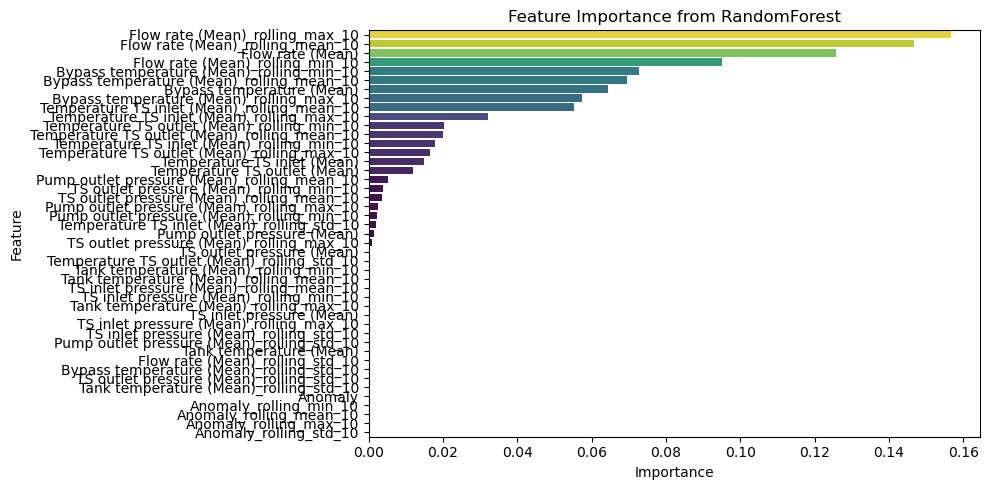

In [8]:
dv.plot_feature_importance(feat_imp)

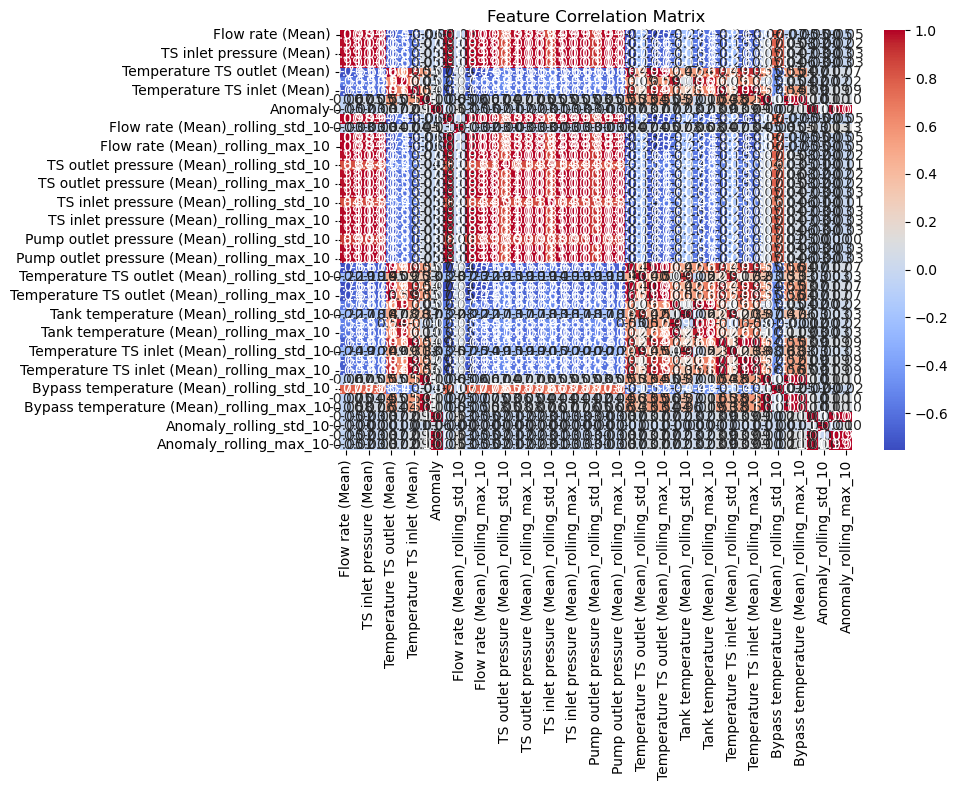

In [9]:
dv.plot_correlation_matrix(X_train)

In [10]:
feat_imp.describe()

count    4.500000e+01
mean     2.222222e-02
std      4.048088e-02
min      6.248544e-14
25%      5.557854e-05
50%      1.281910e-03
75%      1.988934e-02
max      1.566714e-01
dtype: float64

In [11]:
feat_imp.sort_values(ascending=False).head(20)

Flow rate (Mean)_rolling_max_10                 0.156671
Flow rate (Mean)_rolling_mean_10                0.146650
Flow rate (Mean)                                0.125687
Flow rate (Mean)_rolling_min_10                 0.094950
Bypass temperature (Mean)_rolling_min_10        0.072646
Bypass temperature (Mean)_rolling_mean_10       0.069602
Bypass temperature (Mean)                       0.064299
Bypass temperature (Mean)_rolling_max_10        0.057474
Temperature TS inlet (Mean)_rolling_mean_10     0.055242
Temperature TS inlet (Mean)_rolling_max_10      0.032045
Temperature TS outlet (Mean)_rolling_min_10     0.020182
Temperature TS outlet (Mean)_rolling_mean_10    0.019889
Temperature TS inlet (Mean)_rolling_min_10      0.017781
Temperature TS outlet (Mean)_rolling_max_10     0.016441
Temperature TS inlet (Mean)                     0.014772
Temperature TS outlet (Mean)                    0.011928
Pump outlet pressure (Mean)_rolling_mean_10     0.005130
TS outlet pressure (Mean)_rolli

In [12]:
feat_imp.min(), feat_imp.max()

(6.248543964999895e-14, 0.1566713806072437)

In [13]:
X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_low_importance_features(X_train, X_val, X_test, feat_imp / feat_imp.sum())

⚙️ Removed 36 low-importance features (importance < 0.04)
    Remaining features: 9


In [14]:
X_train_reduced.head(5)

,Flow rate (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_min_10,Flow rate (Mean)_rolling_max_10,Temperature TS inlet (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10
0,3.769735,0.705783,3.769339,3.772633,3.766054,-6.131227,0.706074,0.746822,0.665663
1,3.769277,0.671932,3.769110,3.772175,3.766054,-6.144313,0.689142,0.712944,0.665663
2,3.769735,0.711426,3.769186,3.772175,3.766054,-6.146183,0.696668,0.712944,0.671305
3,3.766759,0.694498,3.768481,3.769658,3.766054,-6.148052,0.696198,0.712944,0.671305
4,3.766302,0.705783,3.767966,3.769201,3.766054,-6.148426,0.698173,0.712944,0.671305


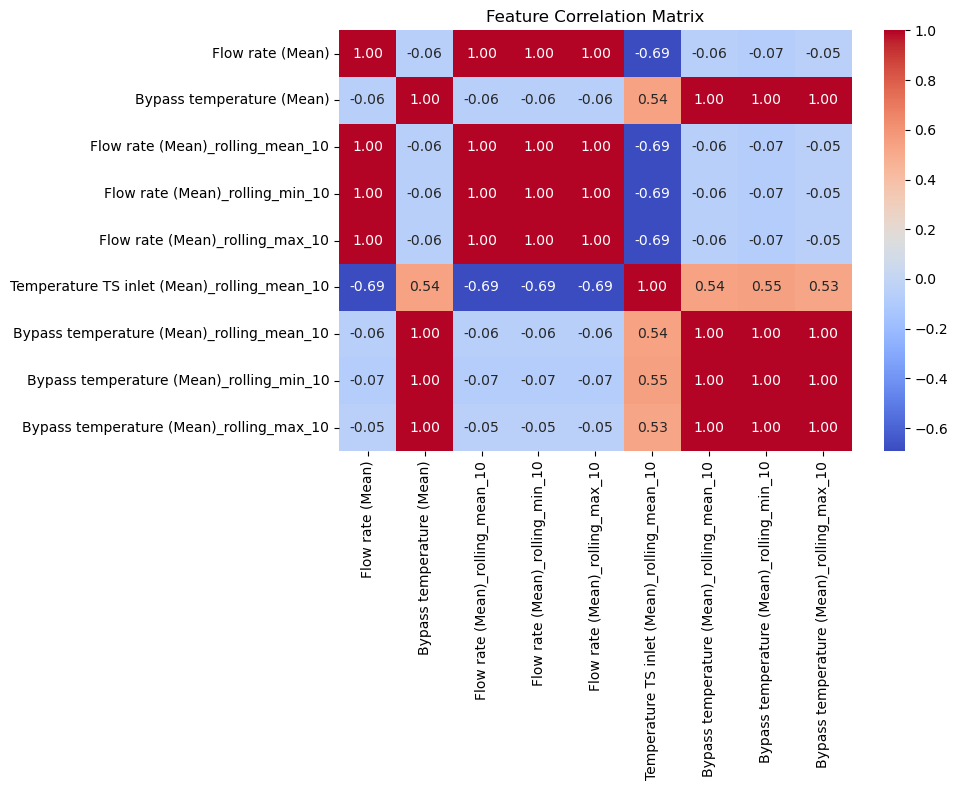

In [15]:
dv.plot_correlation_matrix(X_train_reduced)

In [16]:
y_train.shape

(329747,)

In [17]:
model_reduced = dm.train_and_evaluate_rf(X_train_reduced, X_val_reduced, y_train, y_val)

Validation F1 Score: 0.797


In [18]:
feat_imp_reduced = dp.get_feature_importance(model_reduced, X_train_reduced)

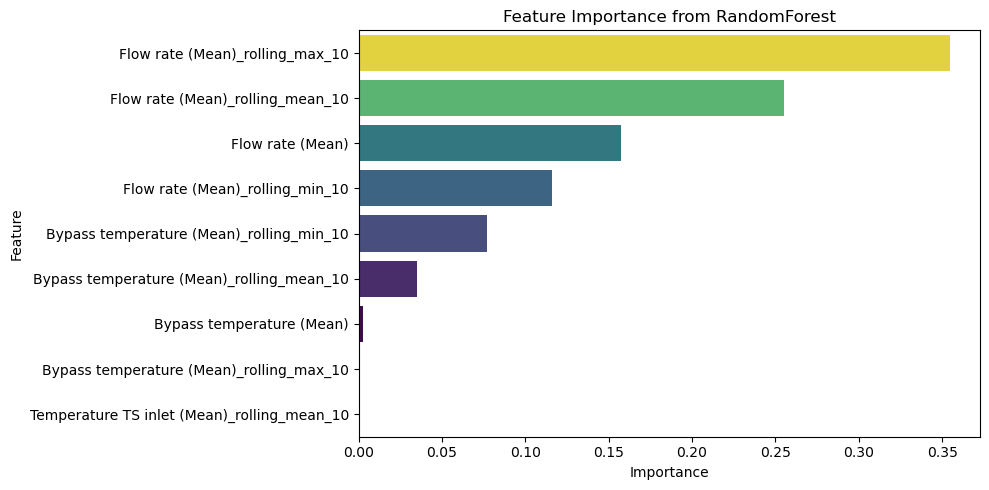

In [19]:
dv.plot_feature_importance(feat_imp_reduced)

### Upsampling

In [20]:
#dm.SMOTE_model(X_train_reduced, y_train, X_val_reduced, y_val)

### Downsampling

In [21]:
#dm.undersample_model(X_train_reduced, y_train, X_val_reduced, y_val)

In [22]:
# Check class balance for the target variable
dp.print_distribution(y_train, "Training set")

Training set distribution:
  Class 0.0: 278514 samples
  Class 1.0: 51233 samples


### Anomaly detection
Testing to see how anomaly detection models do on this dataset.

In [ ]:
models = ad.train_anomaly_models(X_train_reduced, X_val_reduced, y_val)

In [ ]:
dv.plot_discrete_decision_boundry_isolation_forest(models["IsolationForest"], X_val_reduced, y_val)

# Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [23]:
y_train.value_counts(normalize=True)

Plug_future
0.0    0.844629
1.0    0.155371
Name: proportion, dtype: float64

In [24]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val, verbose_level=2, visualize=False)


🔍 Tuning Random Forest...
Searching over 4 hyperparameter combinations...
Params: {'n_estimators': 100, 'max_depth': 10} | Validation F1 Score = 0.7164
Params: {'n_estimators': 100, 'max_depth': 20} | Validation F1 Score = 0.7186
Params: {'n_estimators': 200, 'max_depth': 10} | Validation F1 Score = 0.7164
Params: {'n_estimators': 200, 'max_depth': 20} | Validation F1 Score = 0.7186

✅ Best parameters found: {'n_estimators': 100, 'max_depth': 20}
Best validation F1 Score: 0.7186
Best Random Forest model with params: {'n_estimators': 100, 'max_depth': 20} achieved validation F1 Score: 0.7186

🔍 Tuning Logistic Regression...
Searching over 4 hyperparameter combinations...
Params: {'C': 1.0, 'solver': 'lbfgs'} | Validation F1 Score = 0.6857
Params: {'C': 1.0, 'solver': 'liblinear'} | Validation F1 Score = 0.6963
Params: {'C': 0.5, 'solver': 'lbfgs'} | Validation F1 Score = 0.6916
Params: {'C': 0.5, 'solver': 'liblinear'} | Validation F1 Score = 0.6936

✅ Best parameters found: {'C': 1.0,

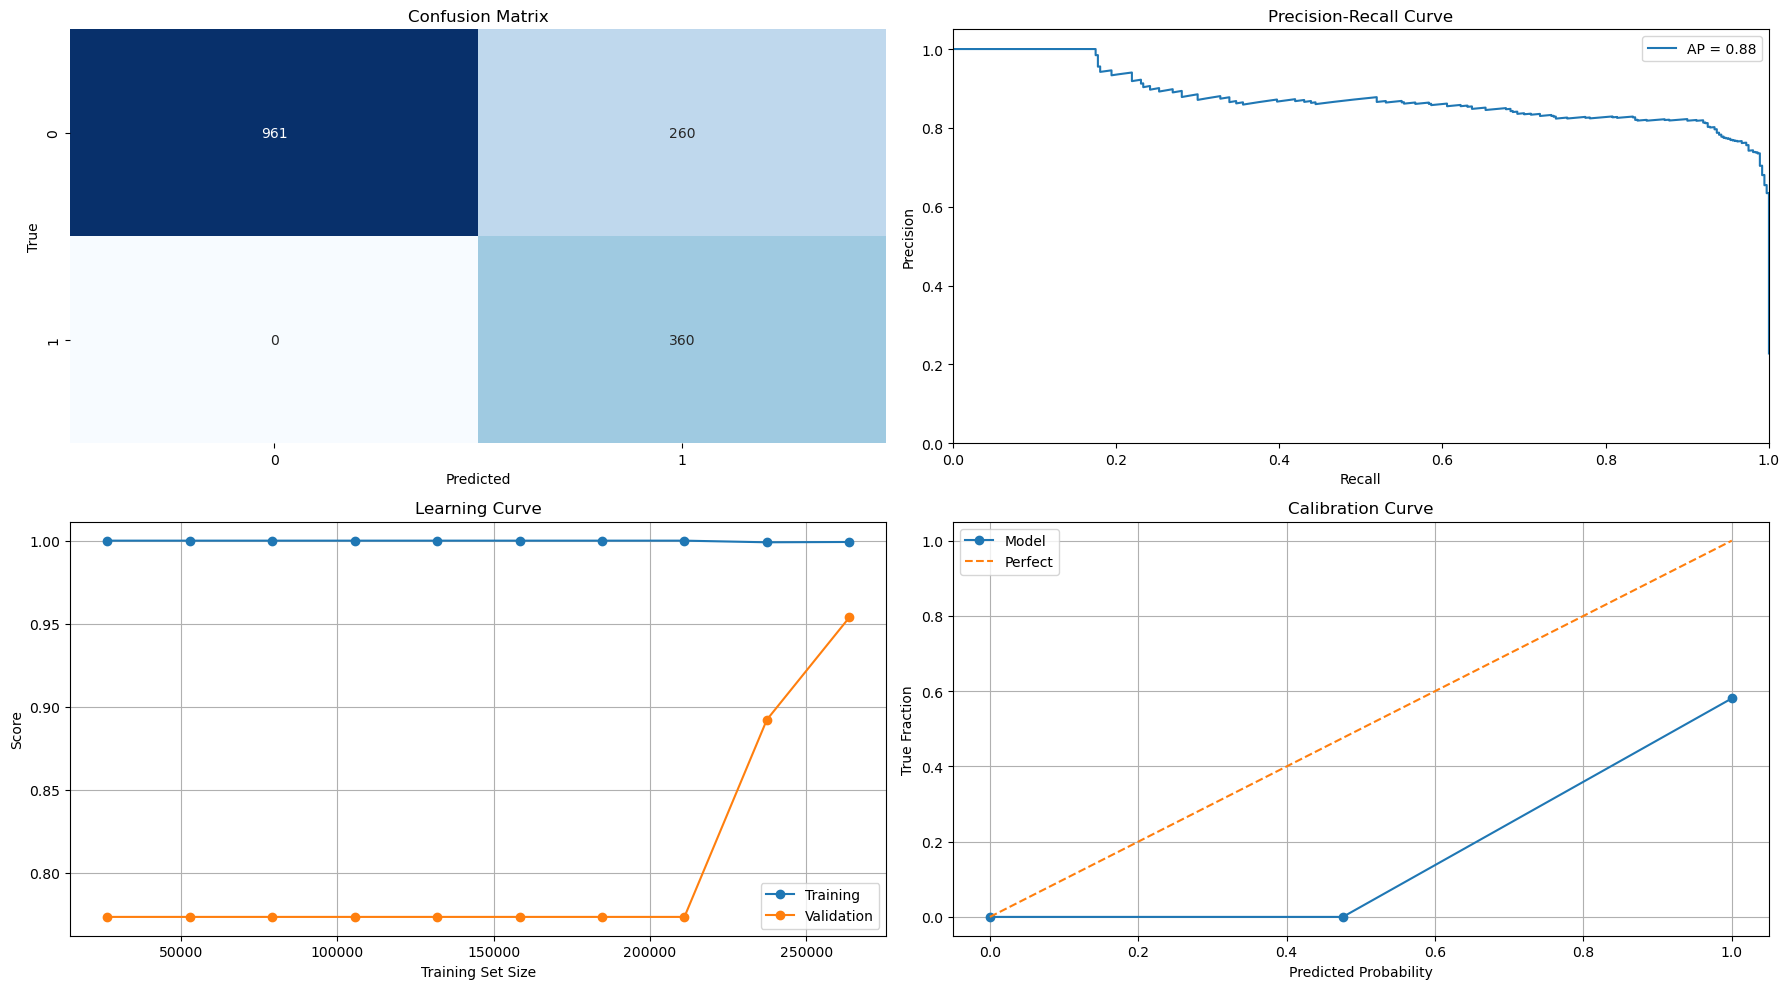

In [25]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_val)

dv.plot_all(best_model, X_val, y_val, train_sizes, train_scores, val_scores)

⚙️ Features descaled using StandardScaler inverse transform


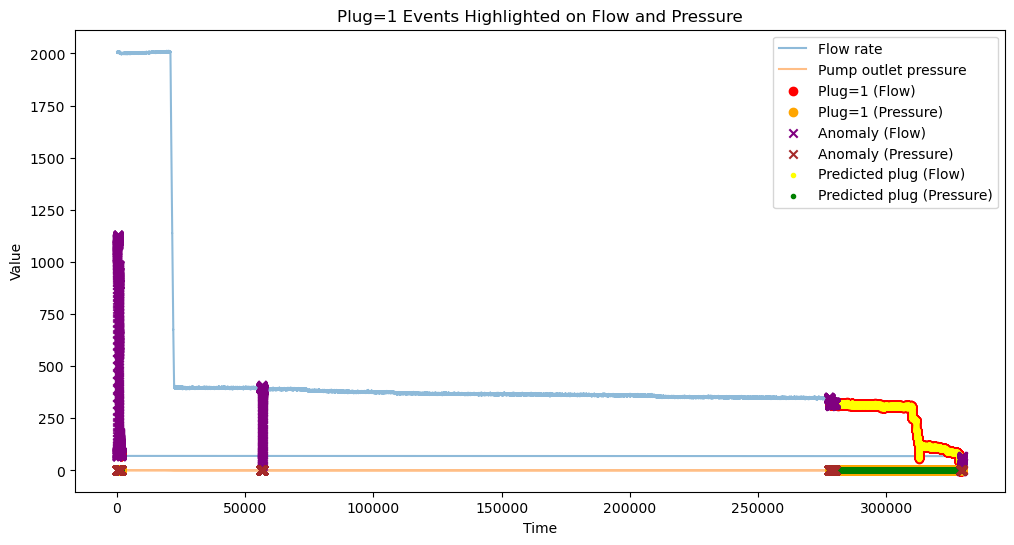

In [26]:
X_all = pd.concat([X_train, X_val])
y_all = pd.concat([y_train, y_val])

y_pred = best_model.predict(X_all)

X_all_unscaled_part = dp.descale_features(X_all)

X_all_unscaled = X_all_unscaled_part.copy()
X_all_unscaled['Plug'] = y_all

dv.visualize_predicted_vs_true(X_all_unscaled, y_pred, anomalies=True)


## Test best model on test dataset
Test the best model on the test dataset to check it´s generalization capabilities.

In [27]:
print(f"Evaluating best model ({best_model.__class__.__name__}) on test set:")
dm.retrain_final_model(X_train, X_val, y_train, y_val, best_model)
y_pred = dm.evaluate_model_on_test(best_model, X_test, y_test)

Evaluating best model (MLPClassifier) on test set:
[1. 1. 1. ... 1. 1. 1.]
Test set results:
              precision    recall  f1-score   support

         0.0      0.000     0.000     0.000         0
         1.0      1.000     0.999     0.999      1582

    accuracy                          0.999      1582
   macro avg      0.500     0.499     0.500      1582
weighted avg      1.000     0.999     0.999      1582

F1 Score: 0.9993674889310563


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Save best model


In [28]:
dm.save_model(best_model, "../models/best_pipeline.joblib")

Saved model to ../models/best_pipeline.joblib


### Visualize performance

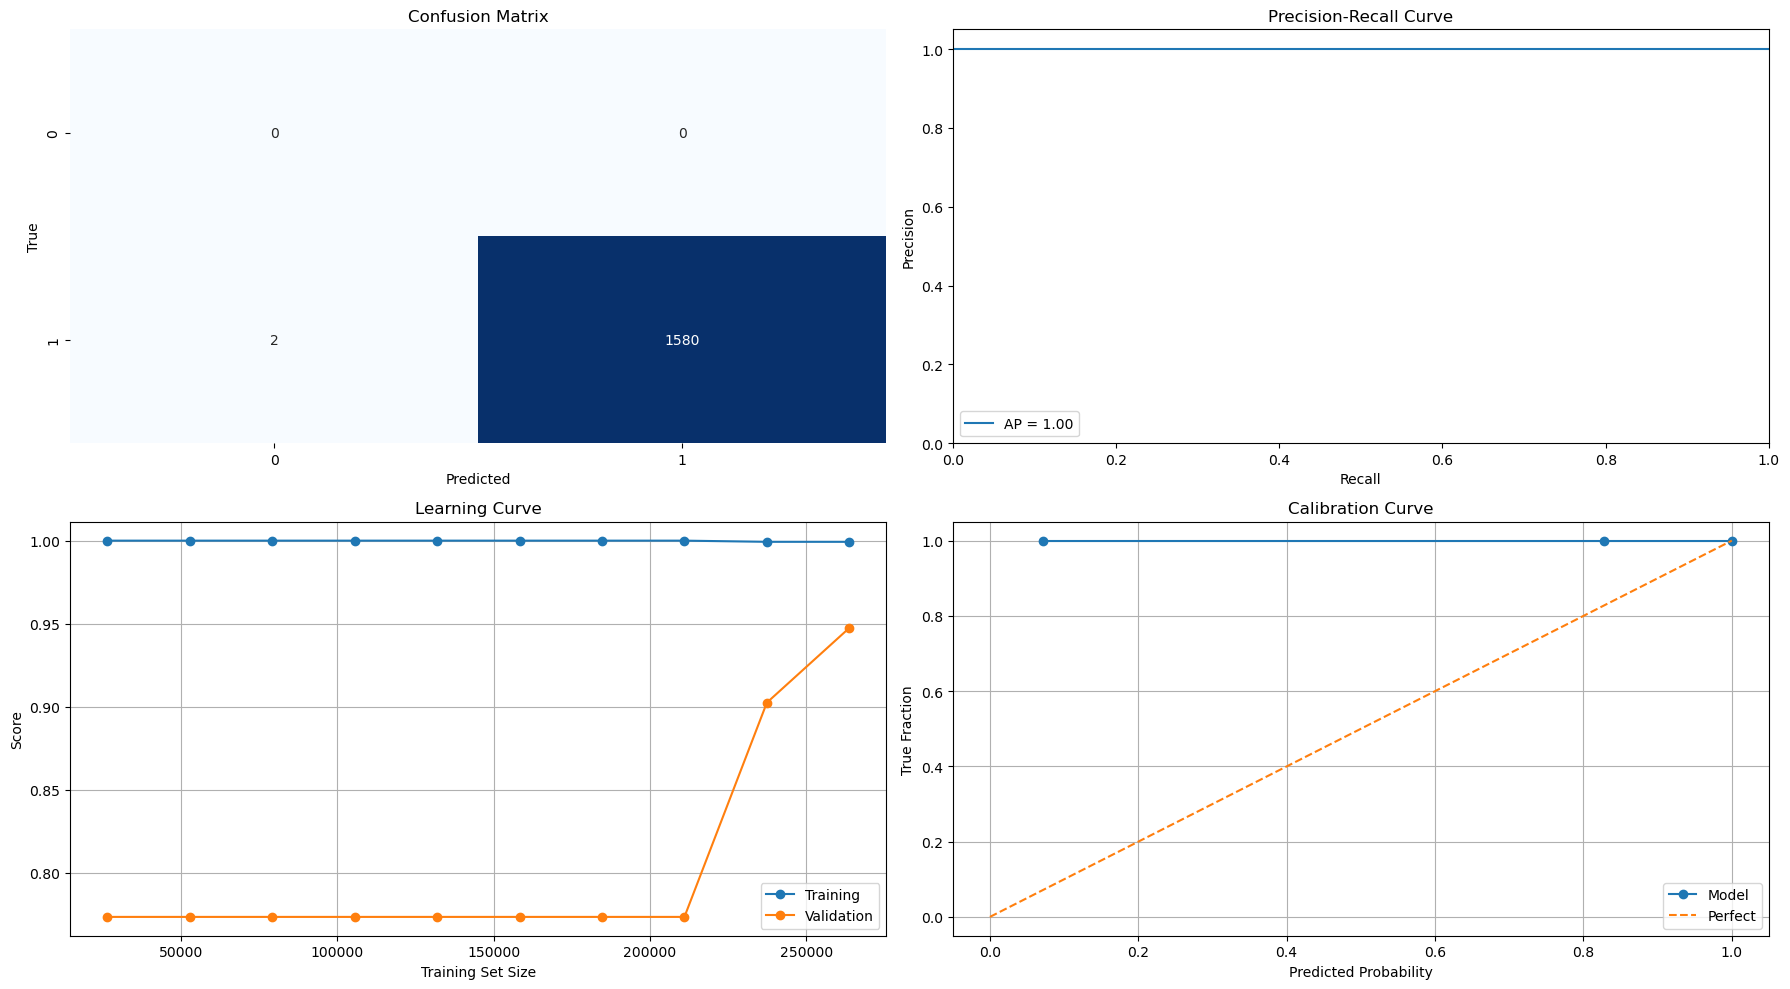

In [29]:
train_sizes, train_scores, val_scores = dm.get_learning_curve_data(best_model, X_train, y_train)
y_pred_proba = dv.get_y_scores(best_model, X_test)

dv.plot_all(best_model, X_test, y_test, train_sizes, train_scores, val_scores)